# Лабораторная работа №2

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error
import numpy as np

from metrics import mse, rmse, mae, r_2, mape
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
data = pd.read_csv("data_sets/air.csv")
data.drop("Unnamed: 0", axis=1, inplace=True)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,year,day,hour,month,day_of_week
0,0.211864,0.511845,0.226923,0.408251,0.118241,0.493333,0.513040,0.455614,0.333333,0.499371,0.280066,0.0,0.3,0.782609,3,3
1,0.161017,0.463029,0.178846,0.352217,0.072819,0.400000,0.453237,0.326806,0.326882,0.484277,0.264282,0.0,0.3,0.826087,3,3
2,0.177966,0.541996,0.171154,0.342365,0.093006,0.497778,0.451439,0.371192,0.296774,0.563522,0.276352,0.0,0.3,0.869565,3,3
3,0.177966,0.523331,0.175000,0.347906,0.122567,0.533333,0.464478,0.427328,0.277419,0.638994,0.294190,0.0,0.3,0.913043,3,3
4,0.127119,0.448672,0.123077,0.278941,0.093006,0.506667,0.422212,0.386858,0.281720,0.633962,0.295216,0.0,0.3,0.956522,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,0.254237,0.478823,0.257692,0.442118,0.338861,0.835556,0.370054,0.656223,0.511828,0.252830,0.279578,1.0,0.1,0.434783,4,1
8871,0.194915,0.370424,0.217308,0.396552,0.253064,0.786667,0.320594,0.456049,0.563441,0.182390,0.257636,1.0,0.1,0.478261,4,1
8872,0.194915,0.355348,0.236538,0.418719,0.209805,0.768889,0.310252,0.379025,0.619355,0.114465,0.222792,1.0,0.1,0.521739,4,1
8873,0.169492,0.255564,0.180769,0.355911,0.167988,0.684444,0.220324,0.238903,0.649462,0.054088,0.160876,1.0,0.1,0.565217,4,1


Для всех моделей в качестве таргета будем использовать `CO(GT)` - количество угарного газа в воздухе.

In [31]:
y = data["CO(GT)"]

In [32]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [33]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Scikit-learn", "Кастомные функции"],
    metrics
])

sklearn_and_custom_comparing = pd.DataFrame(columns=columns)
sklearn_and_custom_comparing

Empty DataFrame
Columns: [(Scikit-learn, R2), (Scikit-learn, MSE), (Scikit-learn, RMSE), (Scikit-learn, MAE), (Scikit-learn, MAPE), (Кастомные функции, R2), (Кастомные функции, MSE), (Кастомные функции, RMSE), (Кастомные функции, MAE), (Кастомные функции, MAPE)]
Index: []

In [34]:
def get_metrics_value(y_predict, y_test):
    sklearn_metrics = [mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error]

    custom_metrics = [mse, rmse, mae, r_2, mape]

    sklearn_metrics_results = []
    custom_metrics_results = []

    for sklearn_metric, custom_metric in zip(sklearn_metrics, custom_metrics):
        sklearn_metrics_results.append(sklearn_metric(y_test, y_predict))
        custom_metrics_results.append(custom_metric(y_test, y_predict))

    return sklearn_metrics_results, custom_metrics_results


### Простая линейная регрессия

Для построения модели простой линейной регрессии в качестве предикта будем использовать признак `PT08.S1(CO)` - показатели датчика S1 об уровне CO в воздухе.

In [35]:
X = data[["PT08.S1(CO)"]]
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.25)

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)
predict_on_test_y = model.predict(X_test)
predict_on_train_y = model.predict(X_train)

Text(0.5, 1.0, 'Простая регрессия')

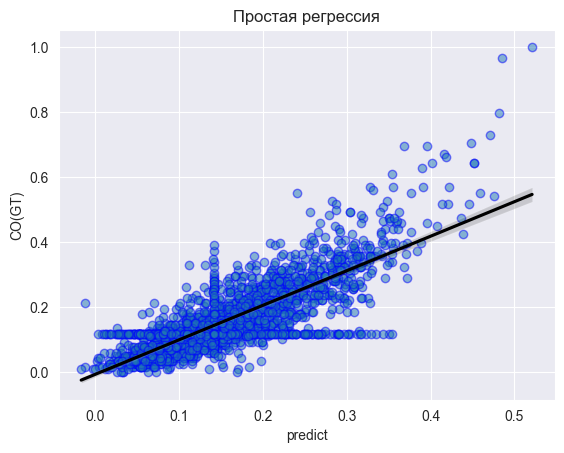

In [37]:
sns.regplot(x=predict_on_test_y, y = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.xlabel("predict")
plt.title("Простая регрессия")

In [38]:
sk_learn_test_metrics, custom_test_metrics = get_metrics_value(predict_on_test_y, y_test)
sklearn_and_custom_comparing.loc["Linear Regression"] = sk_learn_test_metrics + custom_test_metrics
sklearn_and_custom_comparing

Scikit-learn                                              \
                            R2       MSE      RMSE       MAE          MAPE   
Linear Regression     0.004165  0.064537  0.045373  0.651339  8.674291e+11   

                  Кастомные функции                                \
                                 R2       MSE      RMSE       MAE   
Linear Regression          0.004165  0.064537  0.045373  0.651339   

                                 
                           MAPE  
Linear Regression  19261.192814

In [40]:
sk_learn_train_metrics, _ = get_metrics_value(predict_on_train_y, y_train)
train_and_test_comparing.loc["Linear Regression"] = sk_learn_train_metrics + sk_learn_test_metrics
train_and_test_comparing

Train Data                                              \
                          R2       MSE      RMSE       MAE          MAPE   
Linear Regression   0.003668  0.060561  0.043668  0.632086  1.736274e+12   

                  Test Data                                              
                         R2       MSE      RMSE       MAE          MAPE  
Linear Regression  0.004165  0.064537  0.045373  0.651339  8.674291e+11

#### Простая линейная регрессия с регуляризатором L1